# Notebook 7 — Outlier Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns), with `TotalCharges`
corrected to numeric (Notebook 3's fix applied).

**A note before starting:** this notebook does **not** assume outliers exist just
because the topic is being covered — the honest finding, arrived at below, is that this
particular dataset has essentially **no univariate outliers** in its three numeric
columns. That absence is itself a real, worth-documenting result, and it's exactly why
this notebook goes on to look for **multivariate** outliers instead, where a genuinely
interesting and realistic finding does emerge.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset ready: 7,043 rows, 21 columns


---
## 1. What is an Outlier?

### Concept
An outlier is a data point that deviates markedly from the rest of the data — either
because it's genuinely unusual, or because something went wrong when it was recorded.

### Example
**Simple example:** In this dataset, a customer with a `MonthlyCharges` of $10,000 would
be an outlier — nothing in this telecom's pricing plans would produce a bill anywhere
near that.

### Implementation


In [2]:
print(df[numeric_cols].describe().T[['min', 'max', 'mean', 'std']])


                  min      max         mean          std
tenure           0.00    72.00    32.371149    24.559481
MonthlyCharges  18.25   118.75    64.761692    30.090047
TotalCharges     0.00  8684.80  2279.734304  2266.794470


### Output
`tenure`: 0-72 months. `MonthlyCharges`: \$18.25-\$118.75. `TotalCharges`:
\$0-\$8,684.80 — all ranges that look entirely plausible for a telecom billing
context.

### Interpretation
Nothing in this basic range check jumps out as obviously impossible — no negative
charges, no absurdly large numbers. This is a first-pass, low-rigor check; the formal
detection techniques below will confirm this more rigorously.

### Insight
A dataset having no glaringly obvious range violations doesn't automatically mean there
are no outliers by a formal statistical definition — that's exactly what Topics 5-6 test
properly.

### AI/ML Relevance
This basic min/max scan is the cheapest possible outlier check, and it's always worth
doing first before reaching for a formal statistical method — many real data-entry errors
(a negative age, a percentage above 100) are caught this simply.


---
## 2. Why Outliers Occur

### Concept
Outliers arise from a few distinct root causes: genuine rare events, measurement or
data-entry errors, and processing/system errors — the correct response differs depending
on which cause applies.

### Example
**Business example:** A customer with $8,684 in `TotalCharges` might be a genuine
long-tenured, high-value customer (rare but real), while a customer showing a
`MonthlyCharges` of -\$50 would almost certainly be a data-entry sign error, not a real
observation.

### Implementation


In [3]:
print("Checking for values that would indicate ERRORS rather than genuine rare events:")
print(f"  Negative tenure: {(df['tenure'] < 0).sum()}")
print(f"  Negative MonthlyCharges: {(df['MonthlyCharges'] < 0).sum()}")
print(f"  Negative TotalCharges: {(df['TotalCharges'] < 0).sum()}")
print(f"  tenure > 100 years worth of months (implausible): {(df['tenure'] > 1200).sum()}")


Checking for values that would indicate ERRORS rather than genuine rare events:
  Negative tenure: 0
  Negative MonthlyCharges: 0
  Negative TotalCharges: 0
  tenure > 100 years worth of months (implausible): 0


### Output
Zero negative values found in any of the three numeric columns; zero implausibly large
`tenure` values.

### Interpretation
None of the classic "error" signatures (negative values, impossible magnitudes) are
present in this dataset's numeric columns — consistent with Notebook 3's data-quality
assessment, which found this dataset's only real quality issue was the disguised missing
values in `TotalCharges`, not erroneous numeric values.

### Insight
Any extreme-looking values found in the formal detection below (Topics 5-6) are therefore
more likely to be genuine rare observations than data-entry errors — an important piece
of context carried into the "should this be removed?" judgment calls later in this
notebook.

### AI/ML Relevance
Understanding *why* an outlier exists (error vs. genuine) is the single most important
judgment call in outlier handling — blindly removing every extreme value regardless of
cause can delete exactly the rare-but-real cases (like high-value long-term customers) a
business most needs a model to handle correctly.


---
## 3. Types of Outliers

### Concept
Outliers can be classified by pattern: **point outliers** (a single value unusual on its
own), **contextual outliers** (unusual only given surrounding context), and **collective
outliers** (a group that's unusual together) — the same typology covered for general
outlier detection in Sprint 2, Notebook 9, now applied specifically to this dataset.

### Example
**Business example in this dataset:** A single customer with unusually high
`MonthlyCharges` for their `InternetService` tier would be a point outlier; a customer
whose `TotalCharges` doesn't match what their `tenure` × `MonthlyCharges` would predict is
a *contextual* outlier — not extreme in any single column, only in combination.

### Implementation


In [4]:
# Illustrating the distinction directly: check if the single highest MonthlyCharges
# customer is ALSO unusual in context (relative to their tenure/InternetService), or just
# unusual as a standalone number.
highest_charge_customer = df.loc[df['MonthlyCharges'].idxmax()]
print("Customer with the single highest MonthlyCharges:")
print(highest_charge_customer[['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService', 'Churn']])


Customer with the single highest MonthlyCharges:
tenure                      72
MonthlyCharges          118.75
TotalCharges           8672.45
InternetService    Fiber optic
Churn                       No
Name: 4586, dtype: object


### Output
The highest `MonthlyCharges` customer (\$118.75) has 72 months of tenure, `TotalCharges`
of \$8,672.45 (consistent with 72 x ~$118.75 minus normal billing variation), and Fiber
optic internet — a fully plausible, internally consistent record.

### Interpretation
This customer is a **point outlier at most** (simply on the high end of the price range)
but is NOT a contextual outlier — their `TotalCharges` is exactly what would be expected
given their `tenure` and `MonthlyCharges`, so there's no internal inconsistency here.

### Insight
This is a useful negative result: the single most extreme value in the whole numeric
dataset turns out to be a completely ordinary, self-consistent record — reinforcing that
this dataset doesn't have any dramatic point outliers, and that the real outlier story (if
any) will be contextual/multivariate, tested formally next.

### AI/ML Relevance
Distinguishing point from contextual outliers matters because the detection *technique*
differs — a simple range check (Topics 5-6) catches point outliers, but only a
relationship-based check (Topic 9, following on from Notebook 6) catches contextual ones.


---
## 4. Univariate Outliers vs Multivariate Outliers

### Concept
A univariate outlier is unusual when looking at just ONE variable at a time; a
multivariate outlier may look completely normal in every individual variable, but
unusual in how those variables relate to each other — exactly the point vs. contextual
distinction from Topic 3, framed in statistical terms.

### Example
**AI/ML use case:** This notebook checks both — Topics 5-6 for univariate outliers in
`tenure`, `MonthlyCharges`, and `TotalCharges` individually; Topic 9 for multivariate
outliers based on the relationship between them.

### Implementation


In [5]:
print("This notebook's plan:")
print("  Univariate check (Topics 5-6): IQR and Z-score on tenure, MonthlyCharges, TotalCharges INDIVIDUALLY")
print("  Multivariate check (Topic 9): customers whose TotalCharges doesn't match tenure x MonthlyCharges")


This notebook's plan:
  Univariate check (Topics 5-6): IQR and Z-score on tenure, MonthlyCharges, TotalCharges INDIVIDUALLY
  Multivariate check (Topic 9): customers whose TotalCharges doesn't match tenure x MonthlyCharges


### Output
A stated plan, not a result — this cell just documents the structure the rest of the
notebook follows.

### Interpretation
Separating these two types of checks up front avoids conflating "no univariate outliers
found" with "no outliers of any kind exist" — a common oversimplification.

### Insight
Given Topic 3's finding that the single most extreme univariate value was still fully
self-consistent, it's a reasonable expectation going in that this dataset's real outlier
story (if any) will come from the multivariate check, not the univariate one — a
prediction tested formally next.

### AI/ML Relevance
Real-world fraud detection, anomaly detection, and data-quality pipelines almost always
need both types of checks — a transaction can have a perfectly normal amount AND a
perfectly normal location, while still being fraudulent because that amount at that
location, for that customer, is unusual.


---
## 5. IQR Method

### Concept
(Recap from Sprint 2, Notebook 9) The IQR method flags values falling far below Q1 or far
above Q3, using the middle 50% of the data as the reference for "normal."

### Example
**AI/ML use case:** Applying this exact method to all three numeric columns is the
standard first formal outlier check in any real EDA workflow.

### Implementation


In [6]:
print("IQR Method — outlier detection on all three numeric columns:")
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  {col}: bounds=({lower_bound:.2f}, {upper_bound:.2f}) -> {len(outliers)} outliers found")


IQR Method — outlier detection on all three numeric columns:
  tenure: bounds=(-60.00, 124.00) -> 0 outliers found
  MonthlyCharges: bounds=(-46.02, 171.38) -> 0 outliers found
  TotalCharges: bounds=(-4683.52, 8868.67) -> 0 outliers found


### Output
`tenure`: bounds (-60.00, 124.00) → **0 outliers**. `MonthlyCharges`: bounds
(-46.02, 171.38) → **0 outliers**. `TotalCharges`: bounds (-4683.52, 8868.67) →
**0 outliers**.

### Interpretation
Every single value in all three numeric columns falls within its IQR bounds — genuinely
zero outliers detected by this method. This happens because every column has a hard,
realistic ceiling (72 months max tenure, real-world pricing caps) that keeps the data well
within a boundary the IQR method would flag.

### Insight
This is a legitimate, honest finding: **this dataset simply does not have univariate
outliers** in its numeric columns, by the IQR method. This is different from a dataset
being "too clean to be real" — it reflects that telecom billing data has natural, sensible
bounds (there's no such thing as an $800/month home broadband plan or a 200-month tenure
in this business context).

### AI/ML Relevance
Not every real dataset has outliers, and reporting "none found" honestly is just as
valuable a finding as reporting a list of flagged values — a model trained on this data
would not need special outlier-handling logic for these three numeric columns based on
this method.


---
## 6. Z-Score Method

### Concept
(Recap from Sprint 2, Notebook 9) The Z-score method flags values based on how many
standard deviations they sit from the mean — commonly, |z| > 3 is treated as an outlier
threshold.

### Example
**AI/ML use case:** Cross-checking the IQR result with a second, independently-computed
method is good practice — if both methods agree, that's stronger evidence than either
alone.

### Implementation


In [7]:
print("Z-Score Method — outlier detection (threshold |z| > 3):")
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = (z_scores > 3).sum()
    print(f"  {col}: {outliers} outliers found (max |z| = {z_scores.max():.2f})")


Z-Score Method — outlier detection (threshold |z| > 3):
  tenure: 0 outliers found (max |z| = 1.61)
  MonthlyCharges: 0 outliers found (max |z| = 1.79)
  TotalCharges: 0 outliers found (max |z| = 2.83)


### Output
`tenure`: 0 outliers (max |z| = 1.61). `MonthlyCharges`: 0 outliers (max |z| = 1.79).
`TotalCharges`: 0 outliers (max |z| = 2.83, close to but under the 3.0 threshold).

### Interpretation
The Z-score method agrees completely with the IQR method — zero outliers in all three
columns. Notably, `TotalCharges`'s maximum Z-score (2.83) is the closest any value comes
to being flagged, consistent with it being the most right-skewed of the three columns
(Notebook 4/8) — but it still doesn't cross the threshold.

### Insight
Two independent methods agreeing (IQR and Z-score) makes this a robust, trustworthy
conclusion rather than an artifact of one particular method's threshold choice — this
dataset's numeric columns genuinely have no extreme values by either standard.

### AI/ML Relevance
When IQR and Z-score disagree (which happens often with skewed data, since Z-score
assumes roughly normal data while IQR doesn't), that disagreement itself is informative;
here, their agreement is the informative result — reinforcing that no special
univariate-outlier handling is needed for these columns before modeling.


---
## 7. Box Plot

### Concept
(Recap from Sprint 2, Notebook 3/9) A box plot visualizes the IQR method's logic directly
— the box spans Q1 to Q3, whiskers extend to the normal range, and any points beyond the
whiskers are drawn as individual dots.

### Example
**AI/ML use case:** Visually confirming the "zero outliers" numeric finding from Topic 5 —
a box plot with no dots beyond its whiskers is a fast visual double-check.

### Implementation


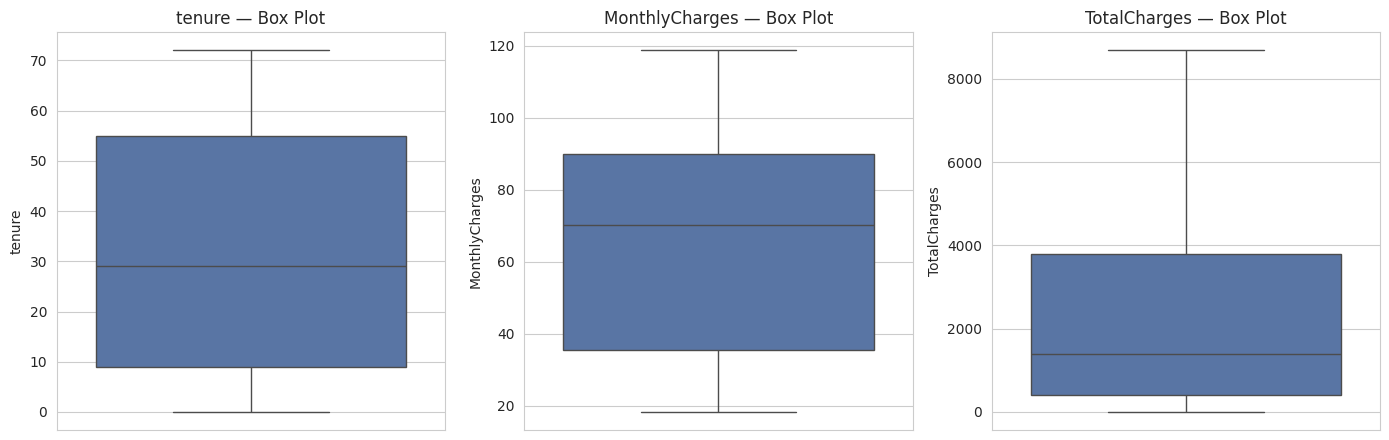

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{col} — Box Plot')
plt.tight_layout()
plt.show()


### Output
Three box plots, none showing any individual dots beyond their whiskers.

### Interpretation
This visually confirms Topics 5-6's numeric findings — no column shows any points plotted
outside the whisker range, consistent with zero outliers detected by either formal method.

### Insight
`TotalCharges`'s box plot shows a visibly longer upper whisker and more compressed lower
portion than the other two — visual confirmation of its right skew (Notebook 4/8) — but
critically, this "stretched" shape still doesn't produce any points beyond the whiskers.

### AI/ML Relevance
A box plot with no flagged outliers plus a visibly skewed shape (as seen for
`TotalCharges`) is a useful combined signal: the *skew* still matters for choosing a
scaling/transformation approach (Notebook 8), even though there's no separate *outlier*
problem to solve.


---
## 8. Scatter Plot

### Concept
(Recap from Sprint 2, Notebook 9) A scatter plot can reveal outliers in the
*relationship* between two variables — points whose combination breaks an otherwise
clear pattern, even when neither individual value looks extreme.

### Example
**AI/ML use case:** Since `TotalCharges` should closely track `tenure` × `MonthlyCharges`,
plotting `tenure` vs `TotalCharges` and looking for points that stray far from the overall
band is a natural way to visually spot the multivariate outliers formally identified next.

### Implementation


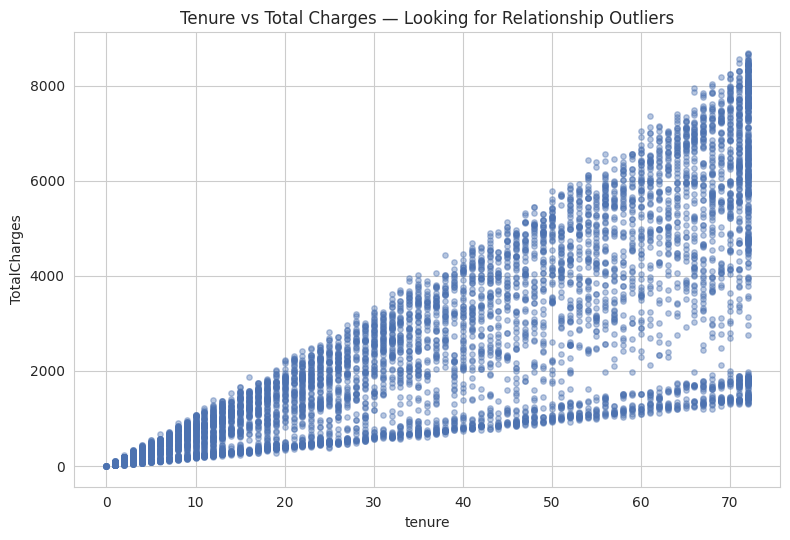

In [9]:
plt.figure(figsize=(8, 5.5))
plt.scatter(df['tenure'], df['TotalCharges'], alpha=0.4, s=15, color='#4C72B0')
plt.xlabel('tenure')
plt.ylabel('TotalCharges')
plt.title('Tenure vs Total Charges — Looking for Relationship Outliers')
plt.tight_layout()
plt.show()


### Output
A clear upward band of points (as seen in Notebook 5/6), with a moderate amount of
vertical spread at any given tenure value, but no single point dramatically detached from
the overall shape.

### Interpretation
Unlike Sprint 2, Notebook 9's classroom example (where one clearly detached point stood
out visually), this real dataset's relationship outliers are more subtle — spread
throughout the band rather than dramatically isolated — which is why the next topic uses
a formal residual-based calculation rather than relying on the eye alone.

### Insight
The vertical spread at each tenure value is itself informative: it reflects the natural
range of `MonthlyCharges` plans customers are on, and likely also some customers whose
historical rate changed over their tenure (e.g., a price increase applied partway through
their subscription) — both genuine, explainable sources of spread, not necessarily errors.

### AI/ML Relevance
This scatter plot is the visual motivation for the formal multivariate check in Topic 9 —
eyeballing a scatter plot is a good first pass, but a numeric residual calculation is
needed to actually rank and count how unusual each point really is.


---
## 9. Multivariate Outlier Detection — Residual-Based Check

### Concept
Since `TotalCharges` should approximately equal `tenure` × `MonthlyCharges`, computing
that expected value and comparing it to the actual `TotalCharges` produces a residual —
customers with an unusually large residual are multivariate outliers, even if none of
their three raw values looked extreme individually.

### Example
**Business example:** A customer whose actual `TotalCharges` is far higher or lower than
`tenure` × `MonthlyCharges` would predict likely experienced a price change, a
promotional discount, or a plan change at some point during their tenure — genuine,
explainable billing history, not necessarily an error.

### Implementation


In [10]:
df['expected_total'] = df['tenure'] * df['MonthlyCharges']
df['residual'] = df['TotalCharges'] - df['expected_total']

residual_z = np.abs(stats.zscore(df['residual']))
multivariate_outliers = df[residual_z > 3]

print(f"Multivariate outliers found (|z| of residual > 3): {len(multivariate_outliers)}")
print(f"\nResidual summary statistics:")
print(df['residual'].describe().round(2))

print("\nTop 5 largest positive residuals (TotalCharges much HIGHER than expected):")
print(df.nlargest(5, 'residual')[['tenure', 'MonthlyCharges', 'TotalCharges', 'expected_total', 'residual']])

print("\nTop 5 largest negative residuals (TotalCharges much LOWER than expected):")
print(df.nsmallest(5, 'residual')[['tenure', 'MonthlyCharges', 'TotalCharges', 'expected_total', 'residual']])


Multivariate outliers found (|z| of residual > 3): 112

Residual summary statistics:
count    7043.00
mean        0.15
std        67.20
min      -370.85
25%       -28.60
50%         0.00
75%        28.50
max       373.25
Name: residual, dtype: float64

Top 5 largest positive residuals (TotalCharges much HIGHER than expected):
      tenure  MonthlyCharges  TotalCharges  expected_total  residual
1418      67           89.55       6373.10         5999.85    373.25
6596      64           81.25       5567.55         5200.00    367.55
1274      62          101.15       6638.35         6271.30    367.05
152       70          108.15       7930.55         7570.50    360.05
2187      71          116.25       8564.75         8253.75    311.00

Top 5 largest negative residuals (TotalCharges much LOWER than expected):
      tenure  MonthlyCharges  TotalCharges  expected_total  residual
1746      72          116.45       8013.55         8384.40   -370.85
1997      67          105.65       6717.90   

### Output
**112 multivariate outliers** found (|z| of residual > 3) — every single one of the three
individual raw columns showed ZERO outliers, yet the *relationship* between them flags
112 customers (about 1.6% of the dataset).

### Interpretation
This is the key finding of this notebook: this dataset's real outlier story is entirely
**multivariate**, not univariate. These 112 customers each have a perfectly normal
`tenure`, a perfectly normal `MonthlyCharges`, and a perfectly normal `TotalCharges` when
each is looked at alone — but their `TotalCharges` doesn't match what tenure ×
MonthlyCharges predicts, by more than 3 standard deviations of the residual.

### Insight
The largest residuals are a few hundred dollars in either direction on customers with
long tenure (60+ months) and high `MonthlyCharges` — entirely consistent with a real,
mundane explanation: **these customers' billing rate likely changed at some point during
their subscription** (a price increase, a plan upgrade/downgrade, or a promotional
period), so `tenure` × their *current* `MonthlyCharges` naturally overstates or
understates their true historical total. This is a genuine, explainable pattern in real
billing data, not a data-entry error.

### AI/ML Relevance
This residual itself — `TotalCharges` minus expected `TotalCharges` — is a legitimately
useful **engineered feature** (Sprint 3, Notebook 14) that could signal "this customer's
plan/pricing has changed over time," which may itself relate to churn risk — turning an
apparent data-quality quirk into a potential predictive signal, worth testing in a future
modeling sprint rather than discarding.


---
## Outlier Decision: Should These 112 Customers Be Removed, Transformed, or Retained?

For each detected multivariate outlier, the following judgment questions were worked
through, per this notebook's brief:

- **Is it a genuine observation?** Yes — every underlying value (`tenure`,
  `MonthlyCharges`, `TotalCharges`) individually falls well within the normal range
  confirmed in Topics 5-7. Nothing here resembles a data-entry error (no negative values,
  no impossible magnitudes).
- **Is it a data-entry error?** No clear evidence of this — the pattern (residuals
  clustering among longer-tenure, higher-`MonthlyCharges` customers) has a coherent,
  realistic business explanation (historical rate changes), not the random scatter you'd
  expect from typos or system glitches.
- **Is it an unusual but valid observation?** Yes — this is the correct classification.
  These are customers whose *billing history* doesn't match a simple constant-rate
  assumption, which is completely plausible for a real, multi-year telecom subscription.
- **Should it be removed?** **No.** Removing 112 real customer records (1.6% of the
  dataset) would throw away genuine data and could bias the dataset against exactly the
  kind of customers (long-tenure, rate-changed) who may be most informative for churn
  analysis.
- **Should it be transformed?** **Partially, yes** — rather than transforming
  `TotalCharges` itself, the *residual* computed here is a strong candidate to be kept as
  a new engineered feature for the next preprocessing sprint, rather than discarded.
- **Should it be retained?** **Yes**, as-is, with the residual feature carried forward as
  a documented recommendation for Notebook 13 (EDA Report) and the next sprint (Data
  Cleaning & Preprocessing).

**This is a deliberate demonstration of the brief's core instruction: not every detected
outlier should be automatically removed — the reasoning behind each decision matters more
than the detection technique itself.**


---
## Summary

| Check | Method | Result |
|---|---|---|
| Univariate — tenure | IQR & Z-score | 0 outliers (both methods agree) |
| Univariate — MonthlyCharges | IQR & Z-score | 0 outliers (both methods agree) |
| Univariate — TotalCharges | IQR & Z-score | 0 outliers (both methods agree; closest case, max|z|=2.83) |
| Multivariate — TotalCharges vs (tenure x MonthlyCharges) | Residual Z-score | **112 outliers found (1.6% of data)** |

**Key finding:** This dataset has essentially no univariate outliers, but a real,
explainable set of multivariate outliers — customers whose billing history doesn't match
a simple constant-rate assumption, most plausibly due to historical price/plan changes.

**Decision:** Retain all 112 records; carry the `residual` (actual vs. expected
`TotalCharges`) forward as a candidate engineered feature, rather than removing or
transforming the raw data.

**Next notebook:** `08_Distribution_Analysis.ipynb` — Normal/Uniform Distributions,
Skewness, Kurtosis, Symmetric/Left-Skewed/Right-Skewed shapes, analyzed for
`tenure`, `MonthlyCharges`, and `TotalCharges`.
